In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent)) # Damit Dataset richtig erkannt wird

In [3]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import PIL.Image as Image
import os
import cv2
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

from SelfAttention.self_attention import SelfAttention
from SelfAttention.MLP import MLP

from TransformerBlocks.ImageTransformerBlock import ImageTransformerBlock
from TransformerBlocks.PointTransformerBlock import PointTransformerBlock

from UNet import FeatureUNET
from PointNet_.PointNet import PointNetAutoencoder, PointNetAutoencoder, PointNetEncoder2D
from PointNet_.PointNetPreTrainer import PointNetPreTrainer
from Dataset.PH2ContourDataset import PH2ContourDataset
from ContourDiffusionModel import ContourDiffusionModel

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

T = 1000  
beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

In [5]:
dataset = PH2ContourDataset(base_path="..\PH2Dataset\PH2 Dataset images", n_punkte=200, img_size=(288, 384)) # eigentlich 576x768, aber das ist zu groß für die GPU. Wir testen erstmal mit 288x384, damit es schneller läuft.

# 2. DataLoader erstellen (z.B. 2 Bilder gleichzeitig verarbeiten)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True, drop_last=True)

# 3. Testen, ob alles klappt:
for batch_images, batch_points, mask in dataloader:
    print("Bild-Batch Form:", batch_images.shape)  
    print("Punkt-Batch Form:", batch_points.shape)     
    print("Mask-Batch Form:", mask.shape)     


Datensatz geladen: 200 Bilder und Masken gefunden.
Bild-Batch Form: torch.Size([1, 3, 288, 384])
Punkt-Batch Form: torch.Size([1, 200, 2])
Mask-Batch Form: torch.Size([1, 1, 288, 384])
Bild-Batch Form: torch.Size([1, 3, 288, 384])
Punkt-Batch Form: torch.Size([1, 200, 2])
Mask-Batch Form: torch.Size([1, 1, 288, 384])
Bild-Batch Form: torch.Size([1, 3, 288, 384])
Punkt-Batch Form: torch.Size([1, 200, 2])
Mask-Batch Form: torch.Size([1, 1, 288, 384])
Bild-Batch Form: torch.Size([1, 3, 288, 384])
Punkt-Batch Form: torch.Size([1, 200, 2])
Mask-Batch Form: torch.Size([1, 1, 288, 384])
Bild-Batch Form: torch.Size([1, 3, 288, 384])
Punkt-Batch Form: torch.Size([1, 200, 2])
Mask-Batch Form: torch.Size([1, 1, 288, 384])
Bild-Batch Form: torch.Size([1, 3, 288, 384])
Punkt-Batch Form: torch.Size([1, 200, 2])
Mask-Batch Form: torch.Size([1, 1, 288, 384])
Bild-Batch Form: torch.Size([1, 3, 288, 384])
Punkt-Batch Form: torch.Size([1, 200, 2])
Mask-Batch Form: torch.Size([1, 1, 288, 384])
Bild-Batch 

In [6]:
ema_unet = FeatureUNET(in_channels=4, out_features=64).to(device)
ema_diff = ContourDiffusionModel(n_punkte=200, hidden_dim=128).to(device)

# HIER IST DER FIX: Lade den besten Checkpoint
checkpoint_pfad = "best_end2end_model_2026-06-04.pth" 
print(f"Lade trainierte Gewichte aus: {checkpoint_pfad}")

# Checkpoint in den RAM/VRAM laden
checkpoint = torch.load(checkpoint_pfad, map_location=device)

print(checkpoint['diff_model_state_dict'].keys())

# Gewichte auf die Modelle anwenden
ema_unet.load_state_dict(checkpoint['unet_state_dict'])
ema_diff.load_state_dict(checkpoint['diff_model_state_dict'])

# Sehr wichtig: Schaltet z.B. Dropout oder BatchNorm-Tracking ab!
ema_unet.eval()
ema_diff.eval()
print("Modelle sind im Evaluierungsmodus und bereit zum Samplen.")

Lade trainierte Gewichte aus: best_end2end_model_2026-06-04.pth
odict_keys(['seq_emb', 'time_mlp.0.weight', 'time_mlp.0.bias', 'time_mlp.2.weight', 'time_mlp.2.bias', 'coord_mlp.weight', 'coord_mlp.bias', 'fusion_mlp.0.weight', 'fusion_mlp.0.bias', 'fusion_mlp.2.weight', 'fusion_mlp.2.bias', 'local_conv1.weight', 'local_conv1.bias', 'transformer.layers.0.self_attn.in_proj_weight', 'transformer.layers.0.self_attn.in_proj_bias', 'transformer.layers.0.self_attn.out_proj.weight', 'transformer.layers.0.self_attn.out_proj.bias', 'transformer.layers.0.linear1.weight', 'transformer.layers.0.linear1.bias', 'transformer.layers.0.linear2.weight', 'transformer.layers.0.linear2.bias', 'transformer.layers.0.norm1.weight', 'transformer.layers.0.norm1.bias', 'transformer.layers.0.norm2.weight', 'transformer.layers.0.norm2.bias', 'transformer.layers.1.self_attn.in_proj_weight', 'transformer.layers.1.self_attn.in_proj_bias', 'transformer.layers.1.self_attn.out_proj.weight', 'transformer.layers.1.self_at

In [7]:
def sample_contour(unet_model, diffusion_model, image_tensor, mask_tensor, T_steps=1000, ddim_steps=50, guidance_scale=4.0):
    with torch.no_grad():
        # Bild + Maske kombinieren für U-Net
        img_with_mask = torch.cat([image_tensor.to(device), mask_tensor.to(device)], dim=1)
        wetterkarte = unet_model(img_with_mask)
        
        # Start: pures Rauschen
        x = torch.randn(1, 200, 2).to(device)
        
        # DDIM: nur 50 Zeitschritte statt 1000
        step_size = T_steps // ddim_steps
        timesteps = list(reversed(range(0, T_steps, step_size)))
        # → [980, 960, 940, ..., 20, 0]
        
        for idx, t in enumerate(tqdm(timesteps, desc=f"DDIM ({ddim_steps} Schritte)", total=len(timesteps))):
            t_tensor = torch.tensor([t], device=device).long()
            
            # x0 direkt vorhersagen mit CFG
            with torch.amp.autocast('cuda'):
                x0_cond   = diffusion_model(x, t_tensor, wetterkarte)
                x0_uncond = diffusion_model(x, t_tensor, [torch.zeros_like(k) for k in wetterkarte])
                predicted_x0 = x0_uncond + guidance_scale * (x0_cond - x0_uncond)
                predicted_x0 = torch.clamp(predicted_x0, -1.2, 1.2)
            
            alpha_t_bar = alphas_cumprod[t]
            
            # Vorheriger Zeitschritt – beim letzten Schritt: alpha=1.0 → x = predicted_x0
            t_prev = timesteps[idx + 1] if idx + 1 < len(timesteps) else -1
            alpha_t_bar_prev = alphas_cumprod[t_prev] if t_prev >= 0 else torch.tensor(1.0, device=device)
            
            # DDIM Update: deterministisch, kein Rauschen
            direction = (x - torch.sqrt(alpha_t_bar) * predicted_x0) / torch.sqrt(1.0 - alpha_t_bar)
            x = torch.sqrt(alpha_t_bar_prev) * predicted_x0 + torch.sqrt(1.0 - alpha_t_bar_prev) * direction
                
    return x

DDIM (50 Schritte): 100%|██████████| 50/50 [00:00<00:00, 81.17it/s]


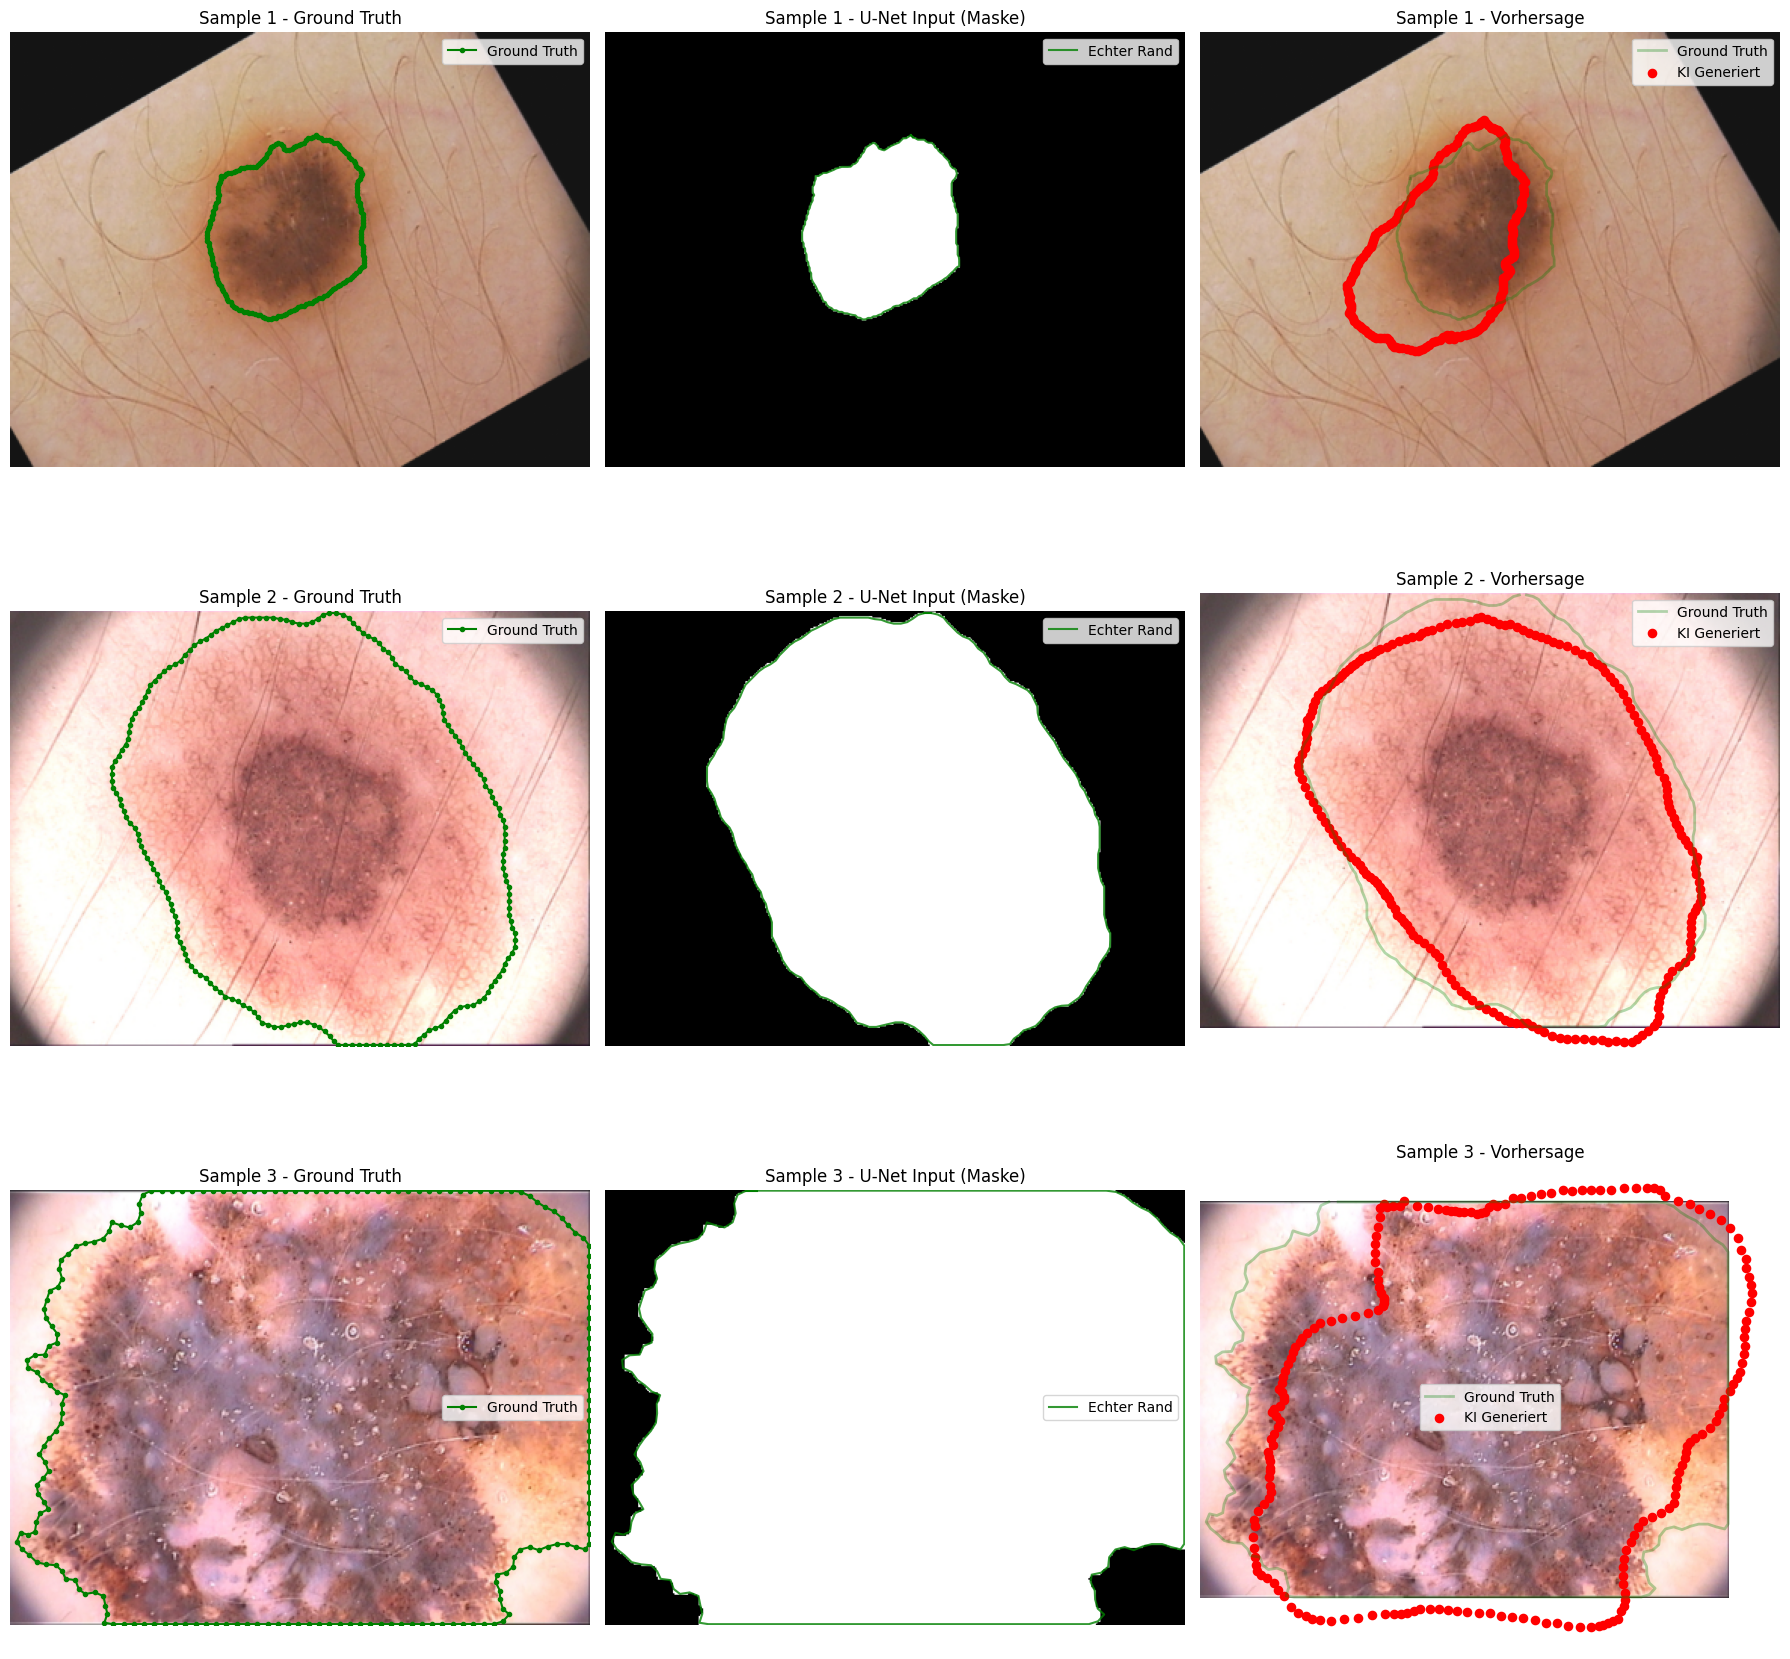

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

T = 1000
beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

ema_unet.eval()
ema_diff.eval()

# --- VISUALISIERUNG ---
# Wir ändern das Grid auf 3 Zeilen und 3 Spalten
fig, axes = plt.subplots(3, 3, figsize=(18, 18))

for i in range(3):
    test_images, test_points, test_masks = next(iter(dataloader))
    
    single_image = test_images[0].unsqueeze(0)
    single_mask = test_masks[0].unsqueeze(0)
    echte_punkte = test_points[0].numpy()

    generierte_punkte = sample_contour(ema_unet, ema_diff, single_image, single_mask, T_steps=T).cpu().squeeze().numpy()

    # Bild vorbereiten
    img_vis = single_image.squeeze().cpu().numpy().transpose(1, 2, 0)
    img_vis = (img_vis * 0.5) + 0.5
    img_vis = np.clip(img_vis, 0, 1)
    H, W = img_vis.shape[:2]

    # Maske für Matplotlib vorbereiten (1-Kanal Tensor zu 2D Array)
    mask_vis = single_mask.squeeze().cpu().numpy()

    gen_x = (generierte_punkte[:, 0] + 1.0) / 2.0 * (W - 1)
    gen_y = (generierte_punkte[:, 1] + 1.0) / 2.0 * (H - 1)
    echt_x = (echte_punkte[:, 0] + 1.0) / 2.0 * (W - 1)
    echt_y = (echte_punkte[:, 1] + 1.0) / 2.0 * (H - 1)

    # --- Spalte 1: Ground Truth ---
    axes[i, 0].imshow(img_vis)
    axes[i, 0].plot(echt_x, echt_y, 'g.-', markersize=6, linewidth=1.5, label="Ground Truth")
    axes[i, 0].plot([echt_x[-1], echt_x[0]], [echt_y[-1], echt_y[0]], 'g-', linewidth=1.5)
    axes[i, 0].set_title(f"Sample {i+1} - Ground Truth")
    axes[i, 0].legend()
    axes[i, 0].axis("off")

    # --- Spalte 2: U-Net Input (Maske) ---
    axes[i, 1].imshow(mask_vis, cmap='gray')
    # Den echten Rand als grüne Linie drüberlegen, um den Versatz durch Dilation/Erosion zu sehen
    axes[i, 1].plot(echt_x, echt_y, 'g-', alpha=0.8, linewidth=1.5, label="Echter Rand")
    axes[i, 1].plot([echt_x[-1], echt_x[0]], [echt_y[-1], echt_y[0]], 'g-', linewidth=1.5)
    axes[i, 1].set_title(f"Sample {i+1} - U-Net Input (Maske)")
    axes[i, 1].legend()
    axes[i, 1].axis("off")

    # --- Spalte 3: Modellvorhersage ---
    axes[i, 2].imshow(img_vis)
    axes[i, 2].plot(echt_x, echt_y, 'g-', alpha=0.3, linewidth=2, label="Ground Truth")
    axes[i, 2].scatter(gen_x, gen_y, c='red', s=35, label="KI Generiert")
    axes[i, 2].set_title(f"Sample {i+1} - Vorhersage")
    axes[i, 2].legend()
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("generierte_konturen_grid_mit_maske.png", bbox_inches='tight', dpi=300)
plt.show()

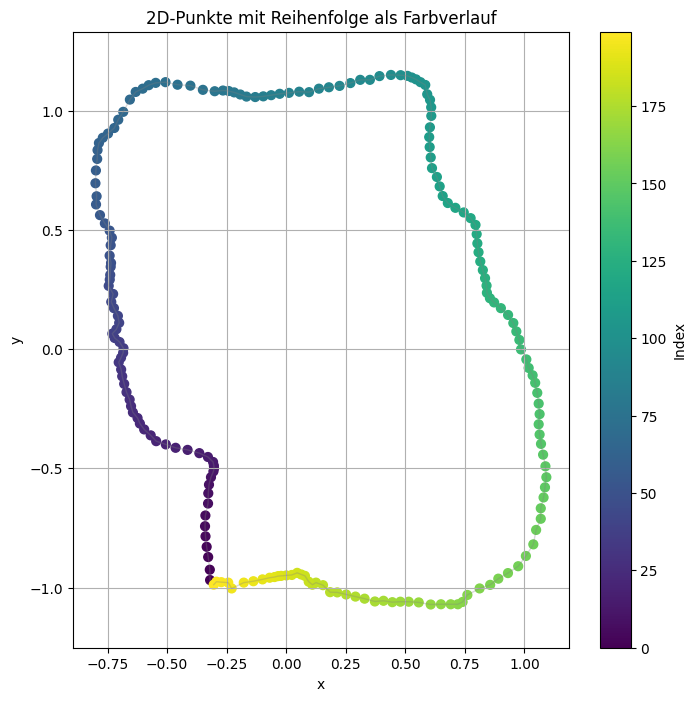

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# generierte_punkte = dein Nx2-Array
# Beispiel:
# generierte_punkte = np.array([...])

punkte = np.asarray(generierte_punkte)

x = punkte[:, 0]
y = punkte[:, 1]

# Farbverlauf entsprechend dem Index
indices = np.arange(len(punkte))

plt.figure(figsize=(8, 8))

scatter = plt.scatter(
    x,
    y,
    c=indices,
    cmap="viridis",
    s=40
)

# Punkte in Reihenfolge verbinden (optional)
plt.plot(x, y, color="gray", alpha=0.3, linewidth=1)

plt.colorbar(scatter, label="Index")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D-Punkte mit Reihenfolge als Farbverlauf")
plt.axis("equal")
plt.grid(True)
plt.show()